## Verify rate of convergence

In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

In [ ]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)


# G_sampler_ls = [ get_G_class(manifold_type, uniform_sampler, 'uniform', {})]
G =  get_G_class(manifold_type, multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2})
# G = get_G_class(manifold_type, equator_sampler, 'equator', {'tau2' : 0.001})
sigma2 = 0.1


test_size = 2500
num_oracle_samples = 2500

NMC = 5


In [5]:
n_samples_ls = [500, 1000, 5000, 10000, 15000, 20000]

test_size = 1000
num_oracle_samples = 5000
M_grid =  [1,2,3,4,5,6,7,8,9,10]
# M_grid = [1,2,3,4,5,6,7,8,9,10,15,20,30,40,50,60] if manifold_type == 'S2' else [1,2,3,4,5,6,7,8,9,10]

rho_grid = [0.5, 0.25, 1e-1, 0.05, 0.025, 1e-2, 1e-4,1e-6,1e-8]
# ---------

all_records = []

oracle_samples = G.sample(num_oracle_samples)  # pre-sample for oracle score estimation across all MC runs
for n_samples in n_samples_ls:

    # losses indexed by [mc, M, rho]
    losses = np.zeros((NMC, len(M_grid), len(rho_grid)), dtype=float)
    displacements = np.zeros((NMC, len(M_grid), len(rho_grid)), dtype=float)
    oracle_losses = np.zeros(NMC, dtype=float)

    for imc in tqdm(range(NMC),
                    desc=f'G "{G.name}", sigma2={sigma2}, n={n_samples}',leave=False,):
        
        Theta = G.sample(n_samples)
        X = manifold.random_riemannian_normal(Theta, 1.0 / sigma2, n_samples)

        test_Theta = G.sample(test_size)
        test_X = manifold.random_riemannian_normal(test_Theta, 1.0 / sigma2, test_size)
                
        # ------ Oracle
        oracle_delta =  oracle_denoiser(manifold_type, oracle_samples, sigma2, test_X)
        oracle_losses[imc] = ( manifold.metric.dist_broadcast(oracle_delta, test_Theta) ** 2).mean()

        # ------ Empirical | grid-search over (M, rho)
        density_onX = [None] * len(M_grid)  
        for ixM, M in enumerate(M_grid):
            density_onX[ixM] = density_estimate(manifold_type, X, M, test_X)

            for ixrho, rho in enumerate(rho_grid):
                delta = denoiser(manifold_type, X, M, rho, sigma2, test_X, densityIn = (density_onX[ixM][1], density_onX[ixM][2]) )
                losses[imc, ixM, ixrho] = ( manifold.metric.dist_broadcast(delta, test_Theta) ** 2).mean()
                displacements[imc, ixM, ixrho] = ( manifold.metric.dist_broadcast(oracle_delta, delta) ** 2).mean()


    # select (M*, rho*) by oracle validation
    mean_loss = losses.mean(axis=0)  # [M, rho]
    mean_displacements = displacements.mean(axis=0)  # [M, rho]
    flat_idx = int(np.argmin(mean_displacements))
    ixM_star, ixrho_star = np.unravel_index(flat_idx, mean_displacements.shape)
    M_star = int(M_grid[ixM_star])
    rho_star = float(rho_grid[ixrho_star])
    empirical_losses = losses[:, ixM_star, ixrho_star]
    
    if False:
        mean_loss_df = pd.DataFrame(mean_loss, index=M_grid, columns=rho_grid)
        mean_loss_df.index.name = "M"
        mean_loss_df.columns.name = "rho"
        print(f"\nmean_loss (G={G.name}, sigma2={sigma2}, n_samples={n_samples})")
        display(mean_loss_df)

    all_records.append(
        {
            "G": G.name,
            "sigma2": float(sigma2),
            "num_samples": int(n_samples),
            "M_star": M_star,
            "rho_star": rho_star,
            "mean_emp_loss": float(losses[:, ixM_star, ixrho_star].mean()),
            "std_emp_loss": float(losses[:, ixM_star, ixrho_star].std()),
            "mean_oracle_loss": float(oracle_losses.mean()),
            "std_oracle_loss": float(oracle_losses.std()),
            "mean_displacement": float(displacements[:, ixM_star, ixrho_star].mean()),
            "std_displacement": float(displacements[:, ixM_star, ixrho_star].std()),
            "mean_excess_loss": float((empirical_losses - oracle_losses).mean()),
            "std_excess_loss": float((empirical_losses - oracle_losses).std()),
        }
    )

   num_samples  M_star  rho_star  mean_excess_loss  mean_displacement
0          500       4     0.250          0.007504           0.005392
1         1000       8     0.100          0.004605           0.004251
2         5000       7     0.025          0.000061           0.002486
3        10000       6     0.025         -0.000295           0.002230
4        15000       6     0.025         -0.000514           0.001923
5        20000       7     0.025         -0.001127           0.001579


/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_6506/696453557.py:21: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)


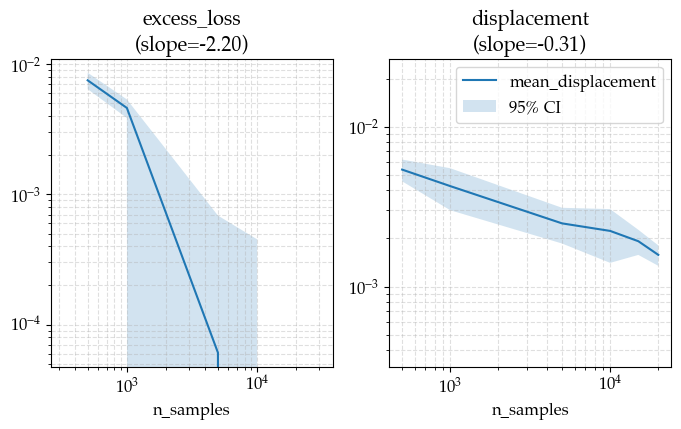

In [7]:
fig, axs = plt.subplots(figsize=(8,4), ncols = 2, sharey = False)
print(pd.DataFrame(all_records).sort_values("num_samples")[['num_samples', 'M_star', 'rho_star', 'mean_excess_loss', 'mean_displacement']])

for variable, ax in zip( [ 'excess_loss', 'displacement'], axs):
    df_rec = pd.DataFrame(all_records).sort_values("num_samples")
    x = df_rec["num_samples"].to_numpy(dtype=float)
    y = df_rec["mean_" + variable].to_numpy(dtype=float)
    ci  = 1.96 * df_rec["std_" + variable].to_numpy(dtype=float) / np.sqrt(NMC)

    # avoid log(0) / negative values
    eps = 0
    y_plot = np.clip(y, eps, None); y_lo = np.clip(y - ci, eps, None); y_hi = np.clip(y + ci, eps, None)
    ax.plot(x, y_plot,label="mean_displacement")
    ax.fill_between(x, y_lo, y_hi, alpha=0.2, label="95% CI")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("n_samples")
    ax.grid(True, which="both", ls="--", alpha=0.4)

    # fit in log-log space: log(y) = a + b*log(x)
    b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)
    ax.set_title(f"{variable}\n(slope={b:.2f})")
    ax.set_aspect("equal", adjustable="datalim")

plt.legend()
plt.show()


In [29]:
(np.zeros(NMC, dtype=float) + np.inf ,) *3 

(array([inf, inf, inf, inf, inf]),
 array([inf, inf, inf, inf, inf]),
 array([inf, inf, inf, inf, inf]))

-----

-----

-----

In [ ]:

all_records = []
# ensure list-like grids
M_grid = list(M_ls)
rho_grid = list(rho_ls)

for sigma2 in sigma2_ls:
    for G in G_sampler_ls:
        for n_samples in n_samples_ls:

            # losses indexed by [mc, M, rho]
            losses = np.zeros((NMC, len(M_grid), len(rho_grid)), dtype=float)
            oracle_losses = np.zeros(NMC, dtype=float)

            for imc in tqdm(
                range(NMC),
                desc=f'G "{G.name}", sigma2={sigma2}, n={n_samples}',
                leave=False,
            ):
                # test set (used for tuning, consistent with your current setup)
                test_Theta = G.sample(test_size)
                test_X = manifold.random_riemannian_normal(test_Theta, 1.0 / sigma2, test_size)

                # training set
                Theta = G.sample(n_samples)
                X = manifold.random_riemannian_normal(Theta, 1.0 / sigma2, n_samples)

                # grid-search over (M, rho)
                for ixM, M in enumerate(M_grid):
                    density_onX = kernel_density_estimate(manifold_type, X, M, test_X)
                    for ixrho, rho in enumerate(rho_grid):
                        delta = denoiser(manifold_type, X, M, rho, sigma2, test_X, densityIn = (density_onX[1], density_onX[2]) )
                        losses[imc, ixM, ixrho] = (
                            manifold.metric.dist_broadcast(delta, test_Theta) ** 2
                        ).mean()

                # oracle Tweedie benchmark on same test set
                oracle_delta_T = oracle_denoiser(
                    manifold_type,
                    num_oracle_samples,
                    sigma2,
                    oracle_bandwidth,
                    test_X,
                    G.sample,
                )
                oracle_losses[imc] = (
                    manifold.metric.dist_broadcast(oracle_delta_T, test_Theta) ** 2
                ).mean()

            # select (M*, rho*) using mean empirical loss across MC
            mean_loss = losses.mean(axis=0)  # [M, rho]
            mean_loss_df = pd.DataFrame(mean_loss, index=M_grid, columns=rho_grid)
            mean_loss_df.index.name = "M"
            mean_loss_df.columns.name = "rho"
            print(f"\nmean_loss (G={G.name}, sigma2={sigma2}, n_samples={n_samples})")
            display(mean_loss_df)
            
            flat_idx = int(np.argmin(mean_loss))
            ixM_star, ixrho_star = np.unravel_index(flat_idx, mean_loss.shape)

            M_star = int(M_grid[ixM_star])
            rho_star = float(rho_grid[ixrho_star])

            empirical_losses = losses[:, ixM_star, ixrho_star]
            diff = empirical_losses - oracle_losses  # Empirical - Oracle, per MC iter

            all_records.append(
                {
                    "G": G.name,
                    "sigma2": float(sigma2),
                    "num_samples": int(n_samples),
                    "M_star": M_star,
                    "rho_star": rho_star,
                    "mean_emp_minus_oracle": float(np.mean(diff)),
                    "std_emp_minus_oracle": float(np.std(diff)),
                    "mean_emp_loss": float(losses[:, ixM_star, ixrho_star].mean()),
                    "std_emp_loss": float(losses[:, ixM_star, ixrho_star].std()),
                    "mean_oracle_loss": float(oracle_losses.mean()),
                    "std_oracle_loss": float(oracle_losses.std()),
                }
            )


mean_loss (G=2-modal, sigma2=0.1, n_samples=100)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.192806,0.191480,0.190914,0.190906,0.190906,0.190906,0.190906,0.190906,0.190906,0.190906
5,0.133123,0.131437,0.130095,0.129070,0.128415,0.128055,0.128018,0.127945,0.127926,0.127926
15,0.111709,0.109588,0.107480,0.105531,0.103737,0.102250,0.101138,0.100196,0.099572,0.097926
25,0.113555,0.111615,0.109564,0.107688,0.105958,0.104668,0.103380,0.102519,0.102156,0.100052
35,0.123253,0.121740,0.120161,0.118879,0.117616,0.117026,0.117068,0.116417,0.117865,0.119416
50,0.153519,0.153294,0.153434,0.154244,0.155346,0.156700,0.157827,0.161924,0.165025,0.184489



mean_loss (G=2-modal, sigma2=0.1, n_samples=500)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.192054,0.190785,0.190208,0.190181,0.190181,0.190181,0.190181,0.190181,0.190181,0.190181
5,0.128434,0.126718,0.125408,0.124361,0.123486,0.123178,0.123051,0.122856,0.122828,0.122828
15,0.101387,0.099131,0.096903,0.094842,0.093233,0.091622,0.090171,0.089565,0.089176,0.087784
25,0.098774,0.096399,0.094208,0.092166,0.090314,0.088573,0.086893,0.085797,0.085917,0.083088
35,0.100803,0.098584,0.096559,0.094758,0.093164,0.091585,0.090043,0.088977,0.089375,0.087096
50,0.108266,0.106511,0.104929,0.103777,0.102743,0.101763,0.101000,0.100473,0.102574,0.104203



mean_loss (G=2-modal, sigma2=0.1, n_samples=1000)


...

rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.192000,0.190606,0.190063,0.190057,0.190057,0.190057,0.190057,0.190057,0.190057,0.190057
5,0.127472,0.125823,0.124351,0.123351,0.122639,0.122395,0.122319,0.122226,0.122196,0.122196
15,0.098842,0.096323,0.094069,0.091882,0.089787,0.088171,0.086830,0.086258,0.086002,0.085495
25,0.094426,0.091618,0.088947,0.086519,0.084067,0.081797,0.079896,0.078731,0.078171,0.077566
35,0.093544,0.090674,0.087829,0.085176,0.082639,0.080038,0.077963,0.076334,0.075678,0.074947
50,0.093984,0.091184,0.088190,0.085376,0.082751,0.080026,0.077680,0.075737,0.075103,0.074250



mean_loss (G=2-modal, sigma2=0.1, n_samples=7500)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.192048,0.190657,0.190112,0.190105,0.190105,0.190105,0.190105,0.190105,0.190105,0.190105
5,0.128016,0.126375,0.124863,0.123883,0.123167,0.122893,0.122820,0.122727,0.122694,0.122694
15,0.099437,0.097152,0.094978,0.092690,0.090674,0.089102,0.087754,0.087081,0.086758,0.085936
25,0.094490,0.091867,0.089532,0.087105,0.084548,0.082477,0.080621,0.079311,0.078697,0.077318
35,0.093010,0.090312,0.087837,0.085400,0.082773,0.080317,0.078368,0.076700,0.075788,0.074152
50,0.092522,0.089840,0.087270,0.084839,0.082204,0.079602,0.077496,0.075696,0.074530,0.072607



mean_loss (G=2-modal, sigma2=0.1, n_samples=10000)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.192068,0.190682,0.190146,0.190138,0.190138,0.190138,0.190138,0.190138,0.190138,0.190138
5,0.127992,0.126365,0.124930,0.123969,0.123286,0.123013,0.122916,0.122824,0.122811,0.122811
15,0.099402,0.097007,0.094832,0.092652,0.090736,0.089192,0.087964,0.087345,0.087060,0.086423
25,0.094531,0.091949,0.089434,0.087046,0.084659,0.082647,0.080975,0.079765,0.079247,0.078261
35,0.093143,0.090476,0.087785,0.085291,0.082784,0.080488,0.078589,0.077104,0.076404,0.075396
50,0.092732,0.089990,0.087290,0.084667,0.082126,0.079624,0.077637,0.075932,0.075052,0.074226


In [ ]:

all_records = []
# ensure list-like grids
M_grid = list(M_ls)
rho_grid = list(rho_ls)

for sigma2 in sigma2_ls:
    for G in G_sampler_ls:
        for n_samples in n_samples_ls:

            # losses indexed by [mc, M, rho]
            losses = np.zeros((NMC, len(M_grid), len(rho_grid)), dtype=float)
            oracle_losses = np.zeros(NMC, dtype=float)

            for imc in tqdm(
                range(NMC),
                desc=f'G "{G.name}", sigma2={sigma2}, n={n_samples}',
                leave=False,
            ):
                # test set (used for tuning, consistent with your current setup)
                test_Theta = G.sample(test_size)
                test_X = manifold.random_riemannian_normal(test_Theta, 1.0 / sigma2, test_size)

                # training set
                Theta = G.sample(n_samples)
                X = manifold.random_riemannian_normal(Theta, 1.0 / sigma2, n_samples)
                oracle_delta_T = oracle_denoiser(
                                manifold_type,
                                num_oracle_samples,
                                sigma2,
                                oracle_bandwidth,
                                test_X,
                                G.sample,
                            )
                # grid-search over (M, rho)
                for ixM, M in enumerate(M_grid):
                    density_onX = kernel_density_estimate(manifold_type, X, M, test_X)
                    for ixrho, rho in enumerate(rho_grid):
                        delta = denoiser(manifold_type, X, M, rho, sigma2, test_X, densityIn = (density_onX[1], density_onX[2]) )
                        losses[imc, ixM, ixrho] = (
                                    manifold.metric.dist_broadcast(delta, oracle_delta_T) ** 2
                                ).mean()

            # select (M*, rho*) using mean empirical loss across MC
            mean_loss = losses.mean(axis=0)  # [M, rho]
            mean_loss_df = pd.DataFrame(mean_loss, index=M_grid, columns=rho_grid)
            mean_loss_df.index.name = "M"
            mean_loss_df.columns.name = "rho"
            print(f"\nmean_loss (G={G.name}, sigma2={sigma2}, n_samples={n_samples})")
            display(mean_loss_df)
            
            flat_idx = int(np.argmin(mean_loss))
            ixM_star, ixrho_star = np.unravel_index(flat_idx, mean_loss.shape)

            M_star = int(M_grid[ixM_star])
            rho_star = float(rho_grid[ixrho_star])


            all_records.append(
                {
                    "G": G.name,
                    "sigma2": float(sigma2),
                    "num_samples": int(n_samples),
                    "M_star": M_star,
                    "rho_star": rho_star,
                    "mean_emp_loss": float(losses[:, ixM_star, ixrho_star].mean()),
                    "std_emp_loss": float(losses[:, ixM_star, ixrho_star].std()),
                }
            )

G "1-modal", sigma2=0.1, n=10:   0%|          | 0/10 [00:00<?, ?it/s]


mean_loss (G=1-modal, sigma2=0.1, n_samples=10)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.111094,0.110992,0.110955,0.110944,0.110941,0.110941,0.110941,0.110941,0.110941,0.110941
5,0.056524,0.055843,0.055225,0.054698,0.054221,0.053803,0.053471,0.053210,0.053053,0.052985
15,0.062375,0.061748,0.061123,0.060471,0.059845,0.059119,0.058408,0.057697,0.056754,0.055276
25,0.133524,0.135070,0.136832,0.138771,0.141165,0.143779,0.147212,0.151939,0.159695,0.188074
35,0.237157,0.242827,0.249397,0.256477,0.263932,0.272848,0.283559,0.297493,0.318042,0.452259
50,0.428614,0.441428,0.455750,0.472303,0.491774,0.515823,0.545017,0.582030,0.637580,1.086614



mean_loss (G=1-modal, sigma2=0.1, n_samples=50)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.113072,0.112966,0.112931,0.112925,0.112922,0.112922,0.112922,0.112922,0.112922,0.112922
5,0.056248,0.055713,0.055212,0.054758,0.054356,0.054037,0.053795,0.053667,0.053618,0.053578
15,0.034130,0.032958,0.031815,0.030733,0.029702,0.028664,0.027583,0.026398,0.025177,0.023807
25,0.046549,0.045710,0.044924,0.044193,0.043557,0.043028,0.042531,0.041960,0.041539,0.041995
35,0.070127,0.070235,0.070487,0.070832,0.071375,0.072103,0.073136,0.074761,0.077015,0.090144
50,0.120848,0.122839,0.125203,0.127816,0.131206,0.135351,0.140404,0.146579,0.156885,0.218396


...

rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.110673,0.110606,0.110587,0.110583,0.110583,0.110583,0.110583,0.110583,0.110583,0.110583
5,0.055930,0.055537,0.055220,0.054947,0.054731,0.054577,0.054483,0.054438,0.054408,0.054408
15,0.026889,0.025838,0.024822,0.023869,0.022980,0.022130,0.021372,0.020721,0.020234,0.019984
25,0.022994,0.021803,0.020609,0.019422,0.018272,0.017176,0.016114,0.015124,0.014294,0.013770
35,0.023687,0.022499,0.021305,0.020100,0.018903,0.017769,0.016683,0.015632,0.014773,0.014279
50,0.028026,0.026939,0.025863,0.024804,0.023740,0.022746,0.021920,0.021203,0.020780,0.021463



mean_loss (G=1-modal, sigma2=0.1, n_samples=750)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.111377,0.111306,0.111278,0.111270,0.111269,0.111269,0.111269,0.111269,0.111269,0.111269
5,0.056342,0.055893,0.055532,0.055237,0.055013,0.054819,0.054672,0.054552,0.054506,0.054506
15,0.027324,0.026206,0.025115,0.024033,0.022989,0.022047,0.021238,0.020499,0.019865,0.019225
25,0.022752,0.021484,0.020209,0.018935,0.017661,0.016375,0.015197,0.014152,0.013167,0.012098
35,0.022413,0.021126,0.019813,0.018485,0.017158,0.015812,0.014539,0.013417,0.012391,0.011481
50,0.024677,0.023453,0.022191,0.020911,0.019642,0.018370,0.017153,0.016231,0.015621,0.016445



mean_loss (G=1-modal, sigma2=0.1, n_samples=1000)


rho,1.000000e-01,8.888889e-02,7.777778e-02,6.666667e-02,5.555556e-02,4.444444e-02,3.333333e-02,2.222222e-02,1.111111e-02,1.000000e-15
M,,,,,,,,,,
1,0.110453,0.110378,0.110360,0.110358,0.110358,0.110358,0.110358,0.110358,0.110358,0.110358
5,0.055140,0.054649,0.054209,0.053862,0.053633,0.053484,0.053383,0.053334,0.053328,0.053328
15,0.025737,0.024672,0.023629,0.022615,0.021596,0.020561,0.019582,0.018749,0.018221,0.017957
25,0.020964,0.019754,0.018538,0.017322,0.016108,0.014876,0.013571,0.012310,0.011271,0.010733
35,0.020307,0.019070,0.017816,0.016557,0.015283,0.014003,0.012636,0.011265,0.010038,0.009556
50,0.021815,0.020609,0.019376,0.018148,0.016923,0.015694,0.014432,0.013113,0.012036,0.012559


In [ ]:
pd.DataFrame(all_records)

,G,sigma2,num_samples,M_star,rho_star,mean_emp_loss,std_emp_loss
0,1-modal,0.1,10,5,1.000000e-15,0.052985,0.004219
1,1-modal,0.1,50,15,1.000000e-15,0.023807,0.007183
2,1-modal,0.1,100,15,1.000000e-15,0.020645,0.009398
3,1-modal,0.1,250,25,1.000000e-15,0.014233,0.002669
4,1-modal,0.1,500,25,1.000000e-15,0.013770,0.003051
5,1-modal,0.1,750,35,1.000000e-15,0.011481,0.001927
6,1-modal,0.1,1000,35,1.000000e-15,0.009556,0.001685
